In [1]:
%pip install gliner2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 89.2 MB/s eta 0:00:00:00:010:01


In [1]:
%pip install "rerankers[transformers]" torch

In [2]:
import duckdb
import numpy as np
import polars as pl
import torch
from sentence_transformers import CrossEncoder, SentenceTransformer
from sklearn.manifold import TSNE
import gliner2

print(torch.cuda.is_available())
con = duckdb.connect("tesco_raw.db")
con.sql("CREATE OR REPLACE SECRET secret (TYPE s3,PROVIDER credential_chain);")
con.sql("SHOW ALL tables")

con.install_extension("vss", repository="core")
con.load_extension("vss")
con.sql('set hnsw_enable_experimental_persistence = True')

False


In [3]:
con.sql("SHOW ALL tables")

┌──────────┬─────────┬─────────┬──────────────┬──────────────┬───────────┐
│ database │ schema  │  name   │ column_names │ column_types │ temporary │
│ varchar  │ varchar │ varchar │  varchar[]   │  varchar[]   │  boolean  │
├──────────┴─────────┴─────────┴──────────────┴──────────────┴───────────┤
│                                 0 rows                                 │
└────────────────────────────────────────────────────────────────────────┘

In [4]:
df = con.sql("""
    WITH cleaned AS (
        SELECT * REPLACE(
            REGEXP_REPLACE(title, REGEXP_ESCAPE(brand), '', 'i') AS title,
            description[1] AS description,
            CASE WHEN quantity IS NULL THEN ROUND(price/unit_price,0)::string ELSE quantity END AS quantity,
            CASE WHEN unit_of_measure IS NULL THEN unit ELSE TRIM(REPLACE(unit_of_measure, 'DR.WT', '')) END AS unit_of_measure)
        FROM tesco_products
    )
    SELECT *,
        CONCAT(title, '. Category: ', shelf) AS product_text
    FROM cleaned
""").pl()

In [26]:
quantities = df["unit_of_measure"].unique().to_list()
quantities

['kg',
 '70cl',
 'litre',
 'SNGL',
 'G',
 'pair',
 'metre',
 '50ml',
 '75cl',
 '100sht',
 'each']

In [27]:
df.filter(pl.col('unit_of_measure') == 'G')

tpnc,title,brand,quantity,unit,price,promotion_start_date,promotion_end_date,unit_price,unit_of_measure,clubcard_price,department,sub_department,aisle,shelf,description,gtin,scraped_at,product_text
str,str,str,str,str,f64,datetime[μs],datetime[μs],f64,str,f64,str,str,str,str,str,str,"datetime[μs, Europe/Dublin]",str
"""297905512""",""" Finest C/Berry,S/Flwr& Pumpki…","""TESCO""","""505""","""G""",null,null,null,null,"""G""",null,"""Bakery""","""From Our Bakery""","""Bread From Our Bakery""","""Sourdough Bread""","""Finest Cranberry, Sunflower & …","""00284750000000""",2026-02-08 23:15:44.855136 GMT,""" Finest C/Berry,S/Flwr& Pumpki…"
"""294765543""",""" Ham Glaze 245G""","""BALLYMALOE""","""245""","""G""",null,null,null,null,"""G""",null,"""Food Cupboard""","""Condiments, Table Sauces, Oliv…","""Condiments, Worcestershire & S…","""Ham Glaze & Christmas Condimen…","""Discover delicious recipes on …","""05099229002068""",2026-02-08 23:15:44.855136 GMT,""" Ham Glaze 245G. Category: Ham…"


In [ ]:
bi_encoder = SentenceTransformer('all-distilroberta-v1')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:

product_titles = df['product_text'].to_list()
product_embeddings = bi_encoder.encode(product_titles,normalize_embeddings=True,show_progress_bar=True)

Batches:   0%|          | 0/604 [00:00<?, ?it/s]

In [8]:
tesco_raw_df = df.with_columns(embeddings = pl.Series(product_embeddings))

In [14]:
# con.execute("ALTER TABLE tesco_products ADD COLUMN embeddings FLOAT[768]")

# # Update from the polars dataframe
# con.execute("""
#     UPDATE tesco_products
#     SET embeddings = tesco_raw_df.embeddings
#     FROM tesco_raw_df
#     WHERE tesco_products.tpnc = tesco_raw_df.tpnc
# """)

con.execute("""
    CREATE OR REPLACE TABLE tesco_products_embeddings
            AS SELECT * FROM tesco_raw_df
""")
con.sql("CREATE INDEX tesco_hnsw_index ON tesco_products_embeddings USING HNSW (embeddings);")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
# def get_text_embedding_list(list_text: list[str]):
#     """
#     Return the list of normalized vector embeddings for list_text.
#     """
#     return bi_encoder.encode(list_text, normalize_embeddings=True)

# con.create_function(
#     "get_text_embedding_list",
#     get_text_embedding_list,
#     return_type='FLOAT[768][]'
# )

input_text_emb_rel = con.sql("""
    select get_text_embedding_list(['protein milk'])[1] as input_text_embedding
""")

tesco_products = con.sql("SELECT * FROM tesco_products_embeddings where brand = 'AVONMORE'")

tesco_products\
.join(input_text_emb_rel, condition="1=1")\
.select("""
        tpnc,
        title,
        brand,
        sub_department,
        aisle,
        shelf,
        unit_price,
        price,
        quantity,
        array_cosine_similarity(
            embeddings,
            input_text_embedding
        )::decimal(3, 2) as cosine_distance_score
    """).order("cosine_distance_score desc").limit(20)

┌───────────┬────────────────────────────────────────┬──────────┬─────────────────────┬───────────────────────────┬─────────────────────┬────────────┬────────┬──────────┬───────────────────────┐
│   tpnc    │                 title                  │  brand   │   sub_department    │           aisle           │        shelf        │ unit_price │ price  │ quantity │ cosine_distance_score │
│  varchar  │                varchar                 │ varchar  │       varchar       │          varchar          │       varchar       │   double   │ double │ varchar  │     decimal(3,2)      │
├───────────┼────────────────────────────────────────┼──────────┼─────────────────────┼───────────────────────────┼─────────────────────┼────────────┼────────┼──────────┼───────────────────────┤
│ 305296165 │  Protein Gold 500Ml                    │ AVONMORE │ Milk, Butter & Eggs │ Fresh Milk                │ Protein Milk        │        4.5 │   2.25 │ 500      │                  0.75 │
│ 293994866 │  Protein Mi

In [103]:
con.sql("""
    SELECT tpnc,title,brand,shelf, fts_main_tesco_products.match_bm25(tpnc, 'protein milk')::decimal as bm25_score
    FROM tesco_products
    WHERE fts_main_tesco_products.match_bm25(tpnc, 'protein milk') IS NOT NULL
    ORDER BY bm25_score DESC
    LIMIT 15
""")

┌───────────┬──────────────────────────────────────────────────────────────────┬──────────┬────────────────────────────┬───────────────┐
│   tpnc    │                              title                               │  brand   │           shelf            │  bm25_score   │
│  varchar  │                             varchar                              │ varchar  │          varchar           │ decimal(18,3) │
├───────────┼──────────────────────────────────────────────────────────────────┼──────────┼────────────────────────────┼───────────────┤
│ 293994866 │ Avonmore Protein Milk 500Ml                                      │ AVONMORE │ Protein Milk               │         3.967 │
│ 293994843 │ Avonmore Protein Milk 1 Litre                                    │ AVONMORE │ Protein Milk               │         3.967 │
│ 296407723 │ Avonmore Protein Milk Chocolate 500Ml                            │ AVONMORE │ Chocolate Milkshake        │         3.661 │
│ 307758584 │ Avonmore Chocolate Protein 

In [14]:
from rerankers import Reranker

ranker = Reranker(
  model_name='cross-encoder/ms-marco-MiniLM-L6-v2',
  model_type='cross-encoder')

Loading TransformerRanker model cross-encoder/ms-marco-MiniLM-L6-v2 (this message can be suppressed by setting verbose=0)
No device set
Using device cpu
No dtype set
Using dtype torch.float32


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model cross-encoder/ms-marco-MiniLM-L6-v2
Using device cpu.
Using dtype torch.float32.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [44]:
pm = ['Tesco Irish Ribeye Steak 454G',
 'IRISH COUNTRY BEEF RIBEYE STEAK 400g',
 'Tesco Finest* Irish Angus Ribeye Steak 454G',
 'Tesco Finest Certified Irish Angus Ribeye Steak 227g',
 'Tesco Finest Certifd Irish Angus Ribeye Joint 1.2Kg',
 'Tesco Sandwich Steak 510G',
 'Tesco Steak Pies 284g',
 'Cookstown Whole Pork Steak 600g',
 'Tesco 2 Steak Bakes',
 'Tesco Irish Gammon Steaks 340G',
 'Tesco Tuna Steaks With A Little Brine 110g',
 'Tesco Irish Sirloin Steak 513G',
 'Tesco Irish Striploin Steak 422G',
 'Mccolgans Steak And Gravy Pie 190G',
 "McColgan's Steak & Gravy Pie 500g",
 'Mogerley Steak And Kidney Pie 190G',
 'Mccagheys Turkey Breast Steaks 460G',
 'Pringles Flamed Grilled Steak 165g',
 'Fray Bentos Steak & Kidney 425G',
 'Tesco Irish Pork Steak']

pml =list(range(len(pm)))

In [50]:
sorted_rows = ranker.rank(
  query="ribeye steak",
  docs=pm,
  doc_ids=pml
)

In [51]:
sorted_rows.results

[Result(document=Document(text='IRISH COUNTRY BEEF RIBEYE STEAK 400g', doc_id=1, metadata={}, document_type='text', image_path=None, base64=None), score=7.352221965789795, rank=1),
 Result(document=Document(text='Tesco Irish Ribeye Steak 454G', doc_id=0, metadata={}, document_type='text', image_path=None, base64=None), score=7.048068523406982, rank=2),
 Result(document=Document(text='Tesco Finest Certified Irish Angus Ribeye Steak 227g', doc_id=3, metadata={}, document_type='text', image_path=None, base64=None), score=6.536720275878906, rank=3),
 Result(document=Document(text='Tesco Finest* Irish Angus Ribeye Steak 454G', doc_id=2, metadata={}, document_type='text', image_path=None, base64=None), score=6.426511764526367, rank=4),
 Result(document=Document(text='Tesco Finest Certifd Irish Angus Ribeye Joint 1.2Kg', doc_id=4, metadata={}, document_type='text', image_path=None, base64=None), score=-0.28791874647140503, rank=5),
 Result(document=Document(text='Tesco Irish Sirloin Steak 513

In [45]:
df = con.sql("SELECT * FROM tesco_products_embeddings").df()

In [102]:
con.sql("SELECT distinct shelf from tesco_products where department = 'Fresh Food'")

┌────────────────────────────┐
│           shelf            │
│          varchar           │
├────────────────────────────┤
│ Cheese Snacking & Minis    │
│ Dates                      │
│ Salami & Meat Snacks       │
│ Soft Cheese & Cream Cheese │
│ Lunchbox Cheese Triangles  │
│ Chorizo                    │
│ Soya Drinks                │
│ Croutons                   │
│ Oat Drinks                 │
│ Low Calorie Ready Meals    │
│     ·                      │
│     ·                      │
│     ·                      │
│ Bacon Ribs                 │
│ Steaks & Fillets           │
│ Pasta Pots                 │
│ Papaya                     │
│ Mushroom & Vegetable Pate  │
│ Smoked Kippers             │
│ Chestnuts                  │
│ Refresher bouquet          │
│ Stir Fry Rice              │
│ Meal Box                   │
├────────────────────────────┤
│    449 rows (20 shown)     │
└────────────────────────────┘

In [62]:
from sklearn.cluster import KMeans

n_clusters = 15
df["embedding"] = df.embeddings.apply(np.array)  # convert string to numpy array
matrix = np.vstack(df.embedding.values)
kmeans = KMeans(n_clusters=n_clusters, init="k-means++", random_state=42)
kmeans.fit(matrix)
labels = kmeans.labels_
df["Cluster"] = labels


Text(0.5, 1.0, 'Clusters identified visualized in language 2d using t-SNE')

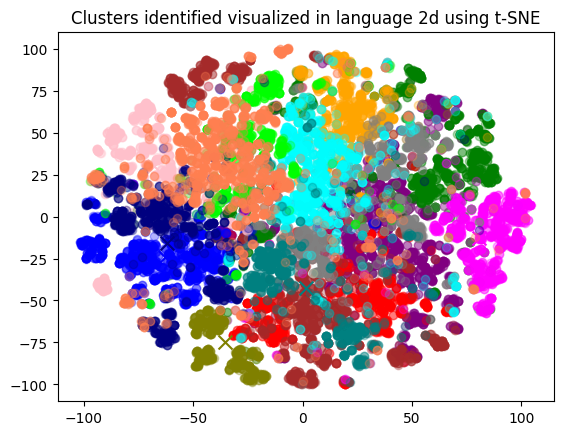

In [ ]:

import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=15, random_state=42, init="random", learning_rate=200)
vis_dims2 = tsne.fit_transform(matrix)

x = [x for x, y in vis_dims2]
y = [y for x, y in vis_dims2]

for category, color in enumerate([
    "purple", "green", "red", "blue", "orange",
    "brown", "pink", "gray", "olive", "cyan",
    "magenta", "lime", "navy", "teal", "coral"
]):
    xs = np.array(x)[df.Cluster == category]
    ys = np.array(y)[df.Cluster == category]
    plt.scatter(xs, ys, color=color, alpha=0.3)

    avg_x = xs.mean()
    avg_y = ys.mean()

    plt.scatter(avg_x, avg_y, marker="x", color=color, s=100)
plt.title("Clusters identified visualized in language 2d using t-SNE")

gliner

--if brand detected use bm25 + semantic else use semantic if search is ambiguous i.e milk could be milk choclate, strawberry milk, regular milk, milk as a descripive adjective for skincare 

--remove quantities fromm title 

In [ ]:
"product variety": {"description": "A product with its variety or type, e.g. white wine, red wine, sparkling water, skimmed milk",
                         "dtype": "list",
                         "threshold": 0.2},

In [ ]:
text = "John works for Apple Inc. and lives in San Francisco."
results = extractor.extract_relations(
    text,
    ["works_for", "lives_in"]
)

In [21]:
from gliner2 import GLiNER2
extractor = GLiNER2.from_pretrained("fastino/gliner2-base-v1")

# Medical entity extraction
supermarket_schema = extractor.create_schema().entities({
    "product": "Generic supermarket product e.g wine,meat,toothpaste",
    "specific product": {"description": "A product with its variety or type, e.g. white wine, red wine, sparkling water, skimmed milk",
                         "dtype": "list",
                         "threshold": 0.8},
    "brand": "Brand Name",
    "supermarket name": "Name of supermarket e.g. Dunnes, Tesco, Supervalu, Aldi",
    "numeric quantity": "Numeric quantity value",
    "quantity unit": "Unit of quantity e.g. g,ml,cl,l,kg"
})

supermarket_query = """
Are maltesers cheaper in dunnes or supervalue
"""

results = extractor.extract(supermarket_query , supermarket_schema,include_confidence=True)
print(results)


You are using a model of type extractor to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-base
Counting layer     : count_lstm_v2
Token pooling      : first
{'entities': {'product': [], 'specific product': [], 'brand': [{'text': 'maltesers', 'confidence': 0.999058187007904}], 'supermarket name': [{'text': 'supervalue', 'confidence': 0.9999996423721313}, {'text': 'dunnes', 'confidence': 0.9999984502792358}], 'numeric quantity': [], 'quantity unit': []}}
